# Defect Detection

 images to vectors then plotting the signals then using polynomial then finding abnormality which are defect (Just work on plain fabrics)

## Simple Example

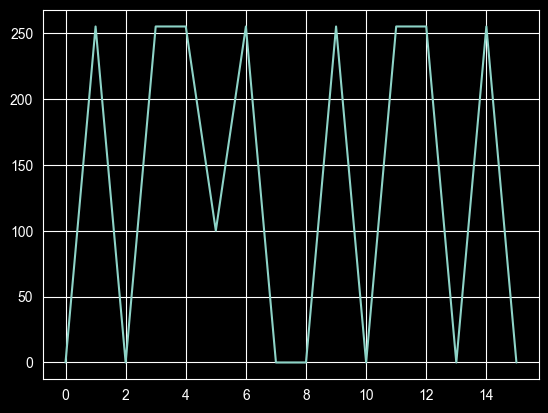

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
X = np.array([0, 255, 0, 255, 255, 100, 255, 0, 0, 255, 0, 255, 255, 0, 255, 0])

plt.plot(X)
plt.show()

## Real Example (web traffic )

In [6]:
df = pd.read_csv('web_traffic.tsv',delimiter='\t')

,day,traffic
0,1,2272.0
1,2,NaN
2,3,1386.0
3,4,1365.0
4,5,1488.0
...,...,...
738,739,4970.0
739,740,4813.0
740,741,5392.0
741,742,5906.0


In [28]:
df.isna().sum()
df = df.dropna()
df.isna().sum()

X = df['day']
y = df['traffic']
X.shape
y.shape

(735,)

C:\Users\top\AppData\Local\Temp\ipykernel_14640\1086740243.py:7: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(X,y,d)
C:\Users\top\AppData\Local\Temp\ipykernel_14640\1086740243.py:7: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(X,y,d)
C:\Users\top\AppData\Local\Temp\ipykernel_14640\1086740243.py:7: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(X,y,d)


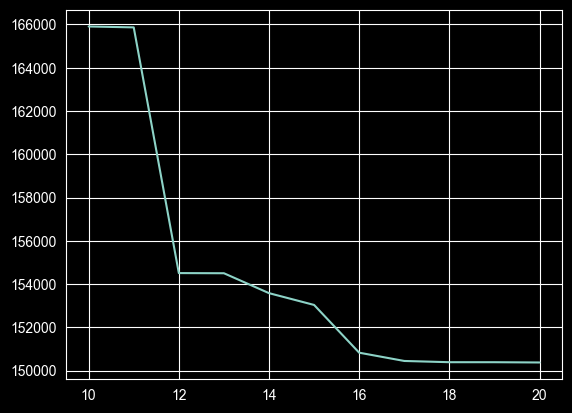

In [40]:
## Find best degree
from sklearn.metrics import mean_squared_error as mse
degree =np.arange(10,21,1)
errors = []

for d in degree :
    coef = np.polyfit(X,y,d)
    y_pred = np.polyval(coef,X)

    msee = mse(y,y_pred)
    errors.append(msee)

plt.plot(degree , errors)

#16 s best


In [42]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
X = df['day'].values.reshape(-1,1)
y = df['traffic']
X_new = PolynomialFeatures(degree=16)
X_true=X_new.fit_transform(X)
X_true

model = LinearRegression()
model.fit(X_true,y)
y_pred = model.predict(X_true)

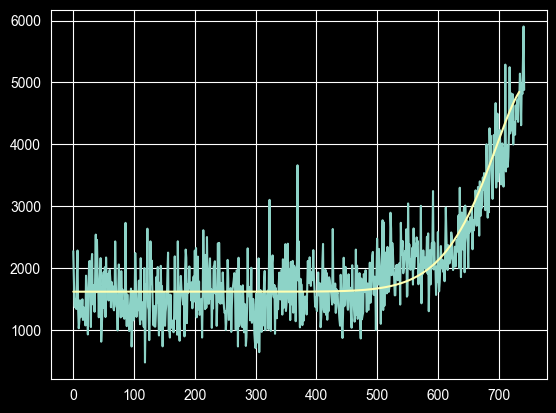

In [44]:
plt.plot(y)
plt.plot(y_pred)

In [77]:
# Determine Margines
residuals = y - y_pred

std = np.std(residuals)

threshold = 2  # or 3 for stricter outlier detection

upper_bound = y_pred + (threshold * std)
lower_bound = y_pred - (threshold * std)

outlier = y[(y>upper_bound) | (y<lower_bound)]

out_x = np.where((y>upper_bound) | (y<lower_bound))
print(outlier.shape)
#print(outlier)
out_x

(28,)


(array([ 35,  83,  92, 114, 118, 143, 206, 212, 263, 276, 292, 298, 315,
        361, 419, 501, 503, 514, 515, 531, 540, 543, 564, 584, 687, 703,
        710, 733], dtype=int64),)

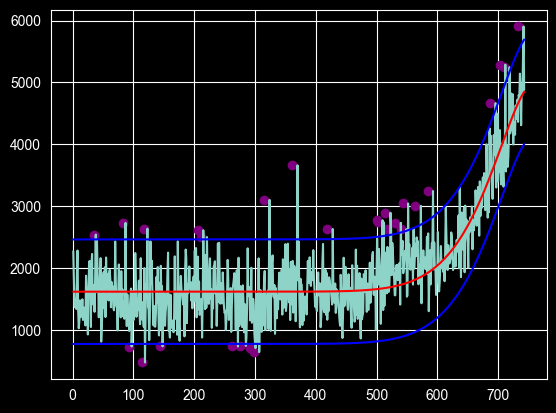

In [82]:
plt.plot(X,y)
plt.plot(X,y_pred,'red')
plt.plot(X,upper_bound,'blue')
plt.plot(X,lower_bound,'blue')

plt.scatter(out_x,outlier,c='purple')


## Real Project (Fabric Defect Detection)

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import cv2

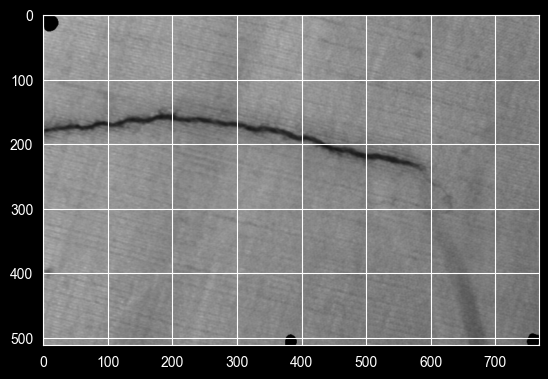

In [88]:
img = cv2.imread('./tilda/c1r1e4n2.tif')#,cv2.IMREAD_GRAYSCALE)
plt.imshow(img)

In [102]:
img = cv2.imread('./tilda/c1r1e4n2.tif',cv2.IMREAD_GRAYSCALE)
img.shape

y = img.ravel()
y.shape

X = np.arange(len(y)).reshape(-1,1)
X.shape

(393216, 1)

C:\Users\top\AppData\Local\Temp\ipykernel_14640\3437543944.py:8: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(X,y,d)
C:\Users\top\AppData\Local\Temp\ipykernel_14640\3437543944.py:8: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(X,y,d)
C:\Users\top\AppData\Local\Temp\ipykernel_14640\3437543944.py:8: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(X,y,d)
C:\Users\top\AppData\Local\Temp\ipykernel_14640\3437543944.py:8: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(X,y,d)
C:\Users\top\AppData\Local\Temp\ipykernel_14640\3437543944.py:8: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(X,y,d)
C:\Users\top\AppData\Local\Temp\ipykernel_14640\3437543944.py:8: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(X,y,d)
C:\Users\top\AppData\Local\Temp\ipykernel_14640\3437543944.py:8: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(X,y,d)


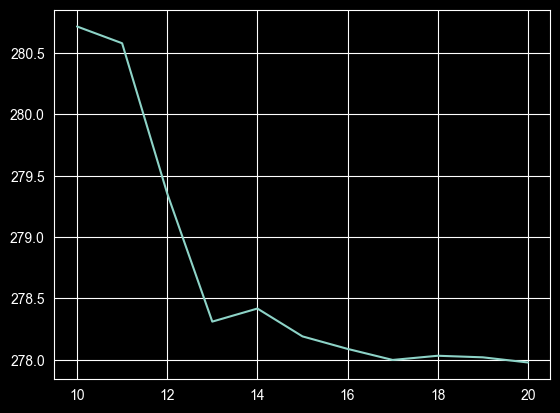

In [104]:
## Find best degree
X = X.ravel()
from sklearn.metrics import mean_squared_error as mse
degree =np.arange(10,21,1)
errors = []

for d in degree :
    coef = np.polyfit(X,y,d)
    y_pred = np.polyval(coef,X)

    msee = mse(y,y_pred)
    errors.append(msee)

plt.plot(degree , errors)

#16 s best


In [108]:
X = X.reshape(-1,1)
X_new = PolynomialFeatures(degree=16)
X_true=X_new.fit_transform(X)

X_true.shape

(393216, 17)

In [109]:
model = LinearRegression()
model.fit(X_true,y)
y_pred = model.predict(X_true)

In [110]:
residuals = y - y_pred
std = np.std(residuals)

In [111]:
upper_bound = y_pred + (3*std)
lower_bound = y_pred - (3*std)
outlier = y[(y>upper_bound) | (y<lower_bound)]
out_x = np.where((y>upper_bound) | (y<lower_bound))

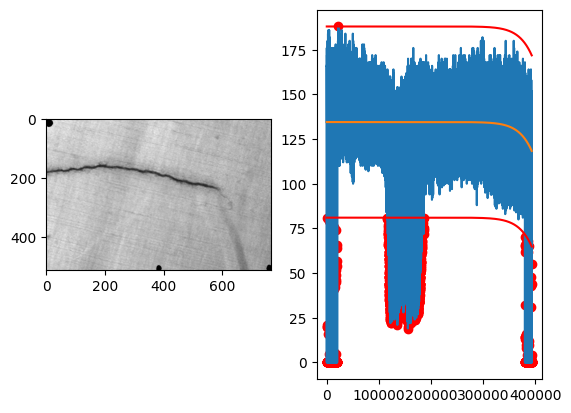

In [120]:
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.subplot(1,2,2)
plt.plot(y)
plt.plot(y_pred)
plt.plot(upper_bound, "r")
plt.plot(lower_bound, "r")

plt.scatter(out_x, outlier, c="red")






## Clustering approach on Fabrics

In [122]:
import cv2
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

you have just one feature think like you have X-axix and then point are located ther based on their number of pixel now clustering based on the nearest of points groups them

In [124]:
img = cv2.imread('./tilda/c1r1e4n2.tif',cv2.IMREAD_GRAYSCALE)
img.shape
img = cv2.medianBlur(img,9)

y = img.ravel()
y.shape

X = np.arange(len(y)).reshape(-1,1)
X.shape

(393216, 1)

In [126]:
y = y.reshape(-1,1)
X
X = X.ravel()
model = KMeans(n_clusters=3)
y_pred= model.fit_predict(y)

result = y_pred.reshape(img.shape)

In [127]:
result

array([[1, 0, 2, ..., 0, 0, 0],
       [0, 2, 2, ..., 0, 0, 0],
       [2, 2, 2, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2]])

(-0.5, 767.5, 511.5, -0.5)

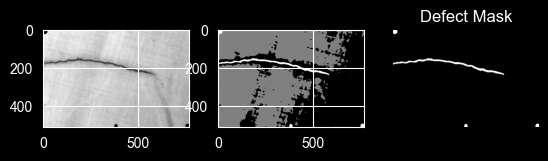

In [135]:
plt.subplot(1,3,1)
plt.imshow(img,cmap='gray')
plt.subplot(1,3,2)
plt.imshow(result,cmap='gray')
plt.subplot(1,3,3)
plt.title("Defect Mask")
plt.imshow(result == 2, cmap="gray")  # highlight one cluster
plt.axis("off")


# just the class 0 become whit other classes become black

How do you decide which cluster is defect?

You must decide manually.

Usually:

Method A (most common)

Assume defect is:

smaller region
rarer pixels
extreme intensity (very dark or very bright)

Example:

cluster_0_mean = img[result == 0].mean()

cluster_1_mean = img[result == 1].mean()

Then decide:

defect_cluster = 0 if cluster_0_mean < cluster_1_mean else 1

In [138]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("./tilda/c1r1e4n2.tif", cv2.IMREAD_GRAYSCALE)
img = cv2.medianBlur(img, 9)

y = img.ravel().reshape(-1,1)
X = np.arange(len(y))

model = KMeans(n_clusters=3, n_init=10, random_state=42)
labels = model.fit_predict(y)

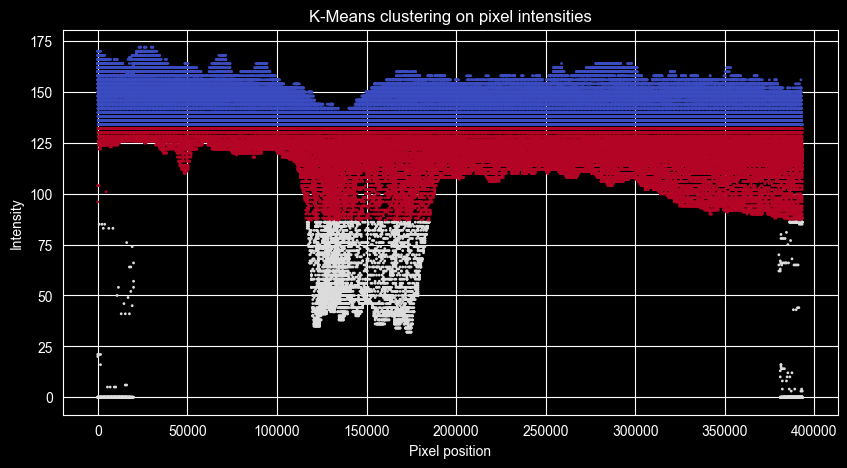

In [141]:
plt.figure(figsize=(10,5))

plt.scatter(X, y, c=labels, cmap='coolwarm', s=1)

plt.title("K-Means clustering on pixel intensities")
plt.xlabel("Pixel position")
plt.ylabel("Intensity")

plt.show()

#The clusters will NOT form a nice shape — they will be scattered along the x-axis.

#Because:

#K-Means clustering does NOT use position (X), only intensity (Y).

#So visually you will see:

#same cluster appearing in many separate regions
#no spatial continuity